In [8]:
import shutil

shutil.rmtree('Covid19-dataset/.ipynb_checkpoints', ignore_errors=True)
shutil.rmtree('Covid19-dataset/train/.ipynb_checkpoints', ignore_errors=True)
shutil.rmtree('Covid19-dataset/test/.ipynb_checkpoints', ignore_errors=True)

print("Deleted checkpoint folders")

Deleted checkpoint folders


In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import os

# ===================================================================
# STEP 1: SETUP AND DATA PREPROCESSING
# ===================================================================

# --- Define Constants and Paths ---
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
base_dir = 'Covid19-dataset'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

# --- Create Data Generators (Preprocessing & Augmentation) ---
print("Creating data generators...")
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# --- Flow data from directories ---
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# ===================================================================
# STEP 2: BUILD AND TRAIN THE CNN MODEL
# ===================================================================

# --- Build the Model Architecture ---
print("Building the model...")
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(3, activation='softmax')
])

# --- Compile the Model ---
print("Compiling the model...")
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# --- Train the Model ---
print("\nStarting model training...")
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=15,
    validation_data=test_generator,
    validation_steps=test_generator.samples // BATCH_SIZE
)

print("\nTraining finished!")

Creating data generators...
Found 251 images belonging to 3 classes.
Found 66 images belonging to 3 classes.
Building the model...
Compiling the model...


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,397,635 (169.36 MB)

 Trainable params: 44,397,635 (169.36 MB)

 Non-trainable params: 0 (0.00 B)


Starting model training...
Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 40s 5s/step - accuracy: 0.3333 - loss: 4.4361 - val_accuracy: 0.6406 - val_loss: 1.0136
Epoch 2/15
1/7 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.5625 - loss: 1.0196

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5625 - loss: 1.0196 - val_accuracy: 0.6562 - val_loss: 0.9818
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 69s 5s/step - accuracy: 0.6301 - loss: 0.8954 - val_accuracy: 0.6875 - val_loss: 0.7435
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5625 - loss: 0.9510 - val_accuracy: 0.7500 - val_loss: 0.6530
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step - accuracy: 0.6712 - loss: 0.7312 - val_accuracy: 0.6875 - val_loss: 0.6609
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 376ms/step - accuracy: 0.5938 - loss: 0.6954 - val_accuracy: 0.7031 - val_loss: 0.6350
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.7626 - loss: 0.5653 - val_accuracy: 0.6562 - val_loss: 0.6578
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7500 - loss: 0.5761 - val_accuracy: 0.6562 - val_loss: 0.7088
Epoch 9/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 83s 8s/step - accuracy: 0.7078 - loss: 0.6738 - val_accuracy: 0.6562 - val_loss: 0.7139
Epoch 10/15
7/7 ━

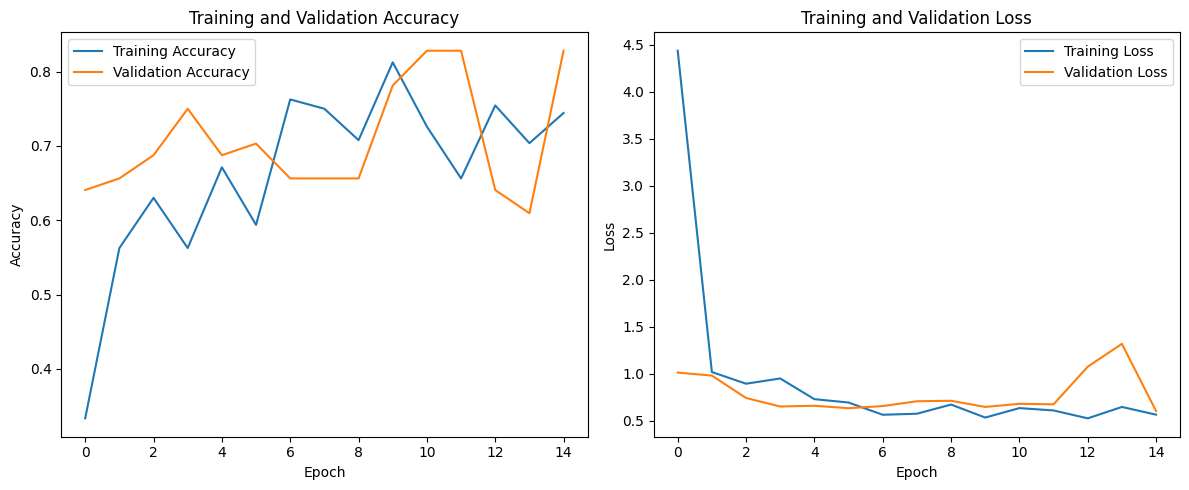

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Plot Training & Validation Accuracy ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# --- Plot Training & Validation Loss ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten

# --- 1. Load the VGG-16 model with pre-trained ImageNet weights ---
# include_top=False means we don't include the final classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_WIDTH, IMG_HEIGHT, 3))

# --- 2. Freeze the convolutional base ---
# We don't want to retrain the existing weights of VGG16
print("Freezing layers in the VGG16 base model...")
for layer in base_model.layers:
    layer.trainable = False

# --- 3. Add our custom classification head ---
# We'll stack our own layers on top of the VGG16 base
x = base_model.output
x = Flatten()(x) # Flatten the output
x = Dense(512, activation='relu')(x) # Add a dense layer
predictions = Dense(3, activation='softmax')(x) # The final prediction layer for our 3 classes

# --- 4. Create the final model ---
transfer_model = Model(inputs=base_model.input, outputs=predictions)

# --- 5. Compile the model ---
print("Compiling the transfer learning model...")
transfer_model.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

transfer_model.summary()

# --- 6. Train the new model ---
print("\nStarting transfer model training...")
history_transfer = transfer_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=10, # We can often train for fewer epochs with transfer learning
    validation_data=test_generator,
    validation_steps=test_generator.samples // BATCH_SIZE
)
print("\nTraining finished!")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Freezing layers in the VGG16 base model...
Compiling the transfer learning model...


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,561,795 (105.14 MB)

 Trainable params: 12,847,107 (49.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


Starting transfer model training...
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 158s 23s/step - accuracy: 0.4018 - loss: 9.8554 - val_accuracy: 0.3281 - val_loss: 5.3757
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 83s 11s/step - accuracy: 0.4062 - loss: 4.6424 - val_accuracy: 0.3281 - val_loss: 5.1002
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 155s 23s/step - accuracy: 0.6438 - loss: 1.6846 - val_accuracy: 0.7812 - val_loss: 0.5499
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 83s 11s/step - accuracy: 0.6250 - loss: 1.1930 - val_accuracy: 0.7344 - val_loss: 0.7364
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 201s 31s/step - accuracy: 0.7169 - loss: 0.8518 - val_accuracy: 0.8281 - val_loss: 0.4013
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 51s 6s/step - accuracy: 0.7812 - loss: 0.7575 - val_accuracy: 0.7812 - val_loss: 0.3889
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 158s 23s/step - accuracy: 0.8036 - loss: 0.5450 - val_accuracy: 0.7812 - val_loss: 0.5497
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 83s 11s/step - accuracy: 0.7778 - loss: 0.6334 - 

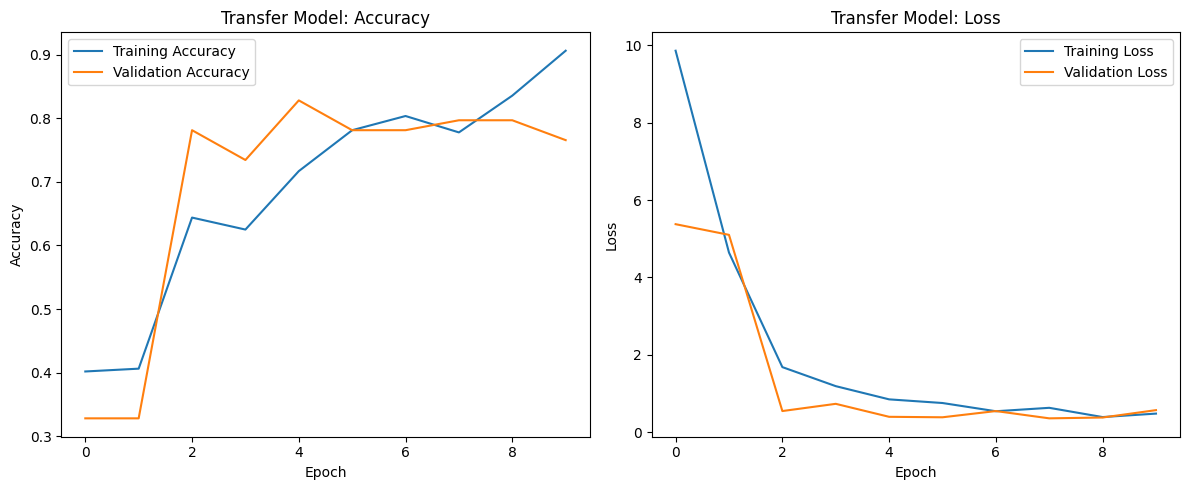

In [12]:
import matplotlib.pyplot as plt

# --- Plot Training & Validation Accuracy ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
# Use the new history object 'history_transfer'
plt.plot(history_transfer.history['accuracy'], label='Training Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Model: Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# --- Plot Training & Validation Loss ---
plt.subplot(1, 2, 2)
# Use the new history object 'history_transfer'
plt.plot(history_transfer.history['loss'], label='Training Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')
plt.title('Transfer Model: Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 9s/step
Classification Report:
                 precision    recall  f1-score   support

          Covid       1.00      0.96      0.98        26
         Normal       1.00      0.30      0.46        20
Viral Pneumonia       0.57      1.00      0.73        20

       accuracy                           0.77        66
      macro avg       0.86      0.75      0.72        66
   weighted avg       0.87      0.77      0.75        66



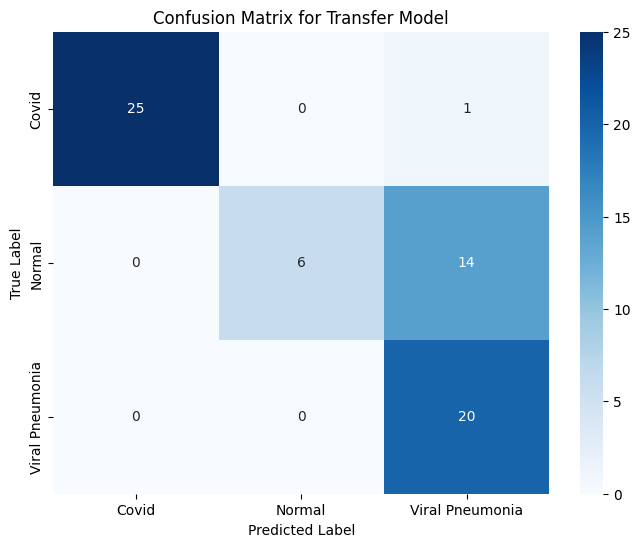

In [13]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# --- Get Predictions from the Transfer Model ---
# Use the new 'transfer_model' to make predictions
predictions = transfer_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# --- Get True Labels ---
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# --- Print Classification Report ---
print("Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

# --- Generate and Plot Confusion Matrix ---
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix for Transfer Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [14]:
# Run this to see the layer names
transfer_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,256,011 (203.16 MB)

 Trainable params: 12,847,107 (49.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 25,694,216 (98.02 MB)

In [15]:
# --- Example Usage ---
# Make sure this path points to a real image in your test set
image_path = 'Covid19-dataset/test/Covid/0102.jpeg'

# This is the name we just found from the summary
last_conv_layer_name = "block5_conv3"

In [16]:
import os

normal_path = 'Covid19-dataset/test/Covid'

print(os.listdir(normal_path)[:20])  # show first 20 files

['auntminnie-2020_01_31_20_24_2322_2020_01_31_x-ray_coronavirus_US.jpg', '0111.jpg', '094.png', '0100.jpeg', '0102.jpeg', '0112.jpg', '096.png', '0118.jpeg', 'auntminnie-a-2020_01_28_23_51_6665_2020_01_28_Vietnam_coronavirus.jpeg', '0115.jpeg', '0120.jpg', 'auntminnie-b-2020_01_28_23_51_6665_2020_01_28_Vietnam_coronavirus.jpeg', '0106.jpeg', '098.jpeg', 'COVID-00022.jpg', 'radiopaedia-2019-novel-coronavirus-infected-pneumonia.jpg', 'auntminnie-c-2020_01_28_23_51_6665_2020_01_28_Vietnam_coronavirus.jpeg', 'COVID-00037.jpg', 'COVID-00012.jpg', '0113.jpg']


Image found at: Covid19-dataset/test/Covid/0102.jpeg. Proceeding with Grad-CAM...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_50']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


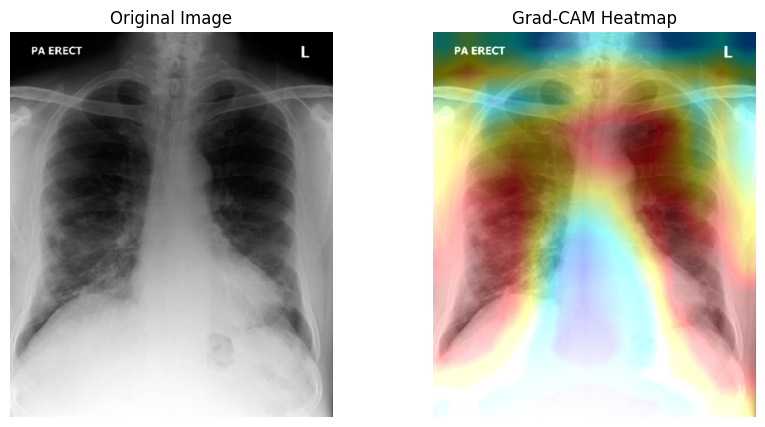

In [17]:
%matplotlib inline
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ===================================================================
# GRAD-CAM HELPER FUNCTIONS
# ===================================================================

def get_img_array(img_path, size):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=size)
    array = tf.keras.preprocessing.image.img_to_array(img)
    array = np.expand_dims(array, axis=0)
    return array

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title("Grad-CAM Heatmap")
    plt.axis('off')
    plt.show()

# ===================================================================
# EXAMPLE USAGE
# ===================================================================

# --- 1. DEFINE YOUR PARAMETERS ---
# !!! IMPORTANT: Update this path to a real image file from your computer !!!
image_path = 'Covid19-dataset/test/Covid/0102.jpeg' # <--- CHANGE THIS LINE

last_conv_layer_name = "block5_conv3"
img_size = (IMG_WIDTH, IMG_HEIGHT)

# --- 2. VERIFY THE IMAGE PATH ---
if not os.path.exists(image_path):
    print(f"ERROR: The image file was not found at the path: {image_path}")
    print("Please make sure the path is correct and try again.")
else:
    print(f"Image found at: {image_path}. Proceeding with Grad-CAM...")
    # --- 3. RUN GRAD-CAM ---
    img_array = get_img_array(image_path, size=img_size)
    img_array_rescaled = img_array / 255.0

    heatmap = make_gradcam_heatmap(img_array_rescaled, transfer_model, last_conv_layer_name)
    display_gradcam(image_path, heatmap)

Automatically found image: Covid19-dataset/test/Covid/0100.jpeg
Proceeding with Grad-CAM...


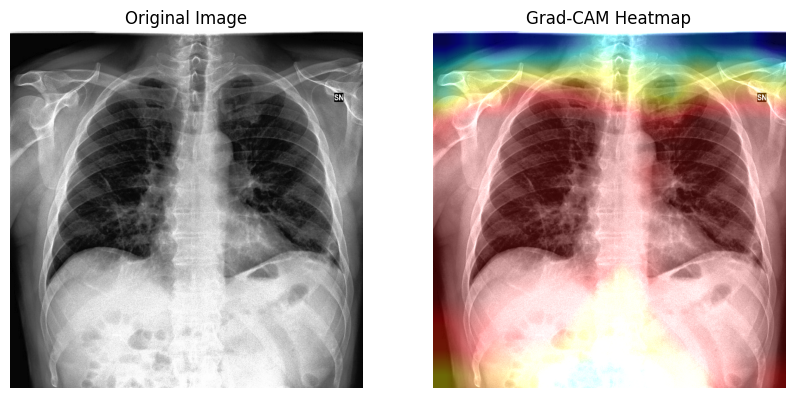

In [18]:
%matplotlib inline
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ===================================================================
# GRAD-CAM HELPER FUNCTIONS (No changes here)
# ===================================================================

def get_img_array(img_path, size):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=size)
    array = tf.keras.preprocessing.image.img_to_array(img)
    array = np.expand_dims(array, axis=0)
    return array

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title("Grad-CAM Heatmap")
    plt.axis('off')
    plt.show()

# ===================================================================
# AUTOMATED FILE FINDER & GRAD-CAM EXECUTION
# ===================================================================

# --- 1. DEFINE PARAMETERS ---
# We will automatically find an image from this folder:
test_image_dir = 'Covid19-dataset/test/Covid/'
last_conv_layer_name = "block5_conv3"
img_size = (IMG_WIDTH, IMG_HEIGHT)

# --- 2. AUTOMATICALLY FIND AN IMAGE FILE ---
image_path = None
if os.path.exists(test_image_dir):
    file_list = os.listdir(test_image_dir)
    if len(file_list) > 0:
        # Find the first JPEG file
        for file in file_list:
            if file.lower().endswith('.jpeg'):
                image_path = os.path.join(test_image_dir, file)
                break
    else:
        print(f"ERROR: The directory '{test_image_dir}' is empty.")
else:
    print(f"ERROR: The directory '{test_image_dir}' was not found.")


# --- 3. RUN GRAD-CAM IF A FILE WAS FOUND ---
if image_path:
    print(f"Automatically found image: {image_path}")
    print("Proceeding with Grad-CAM...")

    img_array = get_img_array(image_path, size=img_size)
    img_array_rescaled = img_array / 255.0

    heatmap = make_gradcam_heatmap(img_array_rescaled, transfer_model, last_conv_layer_name)
    display_gradcam(image_path, heatmap)
else:
    print("Could not find a valid image file to process.")

In [19]:
import os

if os.path.exists('covid_classifier_model.h5'):
    print("Success! The model file 'covid_classifier_model.h5' exists in this directory.")
else:
    print("File not found. You need to save the model first.")
    # --- If the file is not found, uncomment and run the line below ---
    transfer_model.save('covid_classifier_model.h5')
    print("Model has now been saved!")

File not found. You need to save the model first.
Model has now been saved!


In [20]:
# This command saves your trained model to a file
transfer_model.save('covid_classifier_model.h5')

print("Model has been saved successfully!")

Model has been saved successfully!


#Accuracy, Precision, Recall, F1-Score & Confusion Matrix

3/3 ━━━━━━━━━━━━━━━━━━━━ 37s 9s/step
Test Accuracy: 77.27%

Classification Report:

                 precision    recall  f1-score   support

          Covid       1.00      0.96      0.98        26
         Normal       1.00      0.30      0.46        20
Viral Pneumonia       0.57      1.00      0.73        20

       accuracy                           0.77        66
      macro avg       0.86      0.75      0.72        66
   weighted avg       0.87      0.77      0.75        66



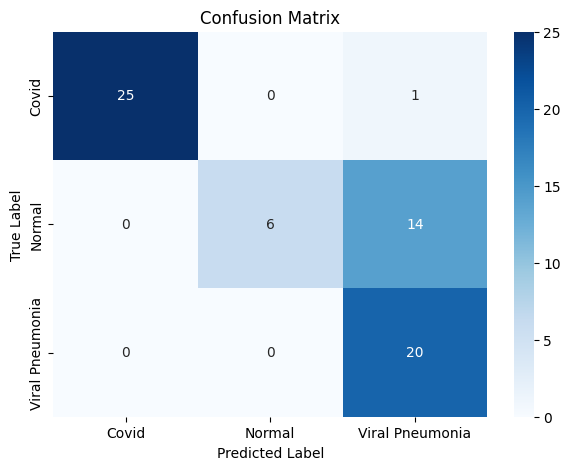

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Reset generator
test_generator.reset()

# Predictions
y_pred_probs = transfer_model.predict(test_generator)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Actual labels
y_true = test_generator.classes

# Class names
class_names = list(test_generator.class_indices.keys())

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

print("="*50)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print("="*50)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#ROC-AUC Score

In [25]:
from sklearn.metrics import roc_auc_score
from tensorflow.keras.utils import to_categorical

# One-hot encode true labels
y_true_onehot = to_categorical(y_true)

# Multi-class ROC-AUC
roc_auc = roc_auc_score(
    y_true_onehot,
    y_pred_probs,
    multi_class='ovr'
)

print(f"ROC-AUC Score (OVR): {roc_auc:.4f}")

ROC-AUC Score (OVR): 0.9812


Save Evaluation Results

In [26]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

import pandas as pd

report_df = pd.DataFrame(report).transpose()

report_df.to_csv("classification_report.csv")

print("Classification report saved as classification_report.csv")

Classification report saved as classification_report.csv
